In [1]:
import seaborn as sns
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import os
import pandas as pd
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
import scipy
from scipy.stats import ttest_ind

In [2]:
os.chdir('...')

da = xr.open_dataset('ANHA4-EJM010_y2017m12d31_gridT.nc')

deptht = da.variables['deptht']
lat = da.variables['nav_lat_grid_T']
lon = da.variables['nav_lon_grid_T']

In [135]:
os.chdir('.../output_miscellaneous/sic')

#avg_ice_cover = np.load('ALL_CASES_Average_IceConcentration_200704_201706.npz')
#avg_ice_cover = avg_ice_cover['ConvE']

#mask = avg_ice_cover > 0.15
#ice_mask = np.copy(avg_ice_cover)
#ice_mask[avg_ice_cover < 0.15] = np.nan\

sic_vs = []
sic_vd = []

for year in range(2007, 2017):
    sic_vs.append(np.load(f'ANHA4-EJM010-S_{year}_ileadfra.npz')['ileadfra'])
    sic_vd.append(np.load(f'ANHA4-EJM012-S_{year}_ileadfra.npz')['ileadfra'])

sic_vs = np.concatenate(sic_vs, axis=0)
sic_vd = np.concatenate(sic_vd, axis=0)

icemask_vs = np.nanmean(sic_vs, axis = 0)
icemask_vd = np.nanmean(sic_vd, axis = 0)

icemask_vs[np.where(icemask_vs < 0.15)] = np.nan
icemask_vd[np.where(icemask_vd < 0.15)] = np.nan

/var/folders/h3/s4smkhd56ks24x42jbqd3gcc0g4l6k/T/ipykernel_1115/2241587679.py:20: RuntimeWarning: Mean of empty slice
  icemask_vs = np.nanmean(sic_vs, axis = 0)


sic_vs: (800, 544)
sic_vd: (180, 800, 544)


/var/folders/h3/s4smkhd56ks24x42jbqd3gcc0g4l6k/T/ipykernel_1115/2241587679.py:21: RuntimeWarning: Mean of empty slice
  icemask_vd = np.nanmean(sic_vd, axis = 0)


In [68]:
os.chdir('/...')

data = xr.open_dataset('ANHA4_mesh_zgr.nc')

lon = data.variables['nav_lon']
lat = data.variables['nav_lat'] 

e1v = data.variables['e1v']
e2u = data.variables['e2u']
e3t = data.variables['e3t_0']

dx = e1v[0]
dy = e2u[0]
e3t = np.copy(e3t[0, 0:50])

In [5]:
os.chdir('.../output_miscellaneous/sic')

In [6]:
ls

ANHA4-EJM010-S_2007_chl.npz  ANHA4-EJM012-S_2007_chl.npz
ANHA4-EJM010-S_2008_chl.npz  ANHA4-EJM012-S_2008_chl.npz
ANHA4-EJM010-S_2009_chl.npz  ANHA4-EJM012-S_2009_chl.npz
ANHA4-EJM010-S_2010_chl.npz  ANHA4-EJM012-S_2010_chl.npz
ANHA4-EJM010-S_2011_chl.npz  ANHA4-EJM012-S_2011_chl.npz
ANHA4-EJM010-S_2012_chl.npz  ANHA4-EJM012-S_2012_chl.npz
ANHA4-EJM010-S_2013_chl.npz  ANHA4-EJM012-S_2013_chl.npz
ANHA4-EJM010-S_2014_chl.npz  ANHA4-EJM012-S_2014_chl.npz
ANHA4-EJM010-S_2015_chl.npz  ANHA4-EJM012-S_2015_chl.npz
ANHA4-EJM010-S_2016_chl.npz  ANHA4-EJM012-S_2016_chl.npz


In [ ]:
os.chdir('.../output_miscellaneous/chl')
chl = np.load('ANHA4-EJM012-S_2013_chl.npz')
chl = chl['chl']
date = chl['date']

In [ ]:
print(date)

In [8]:
os.chdir('.../output_miscellaneous/po4')
po4 = np.load('ANHA4-EJM012-S_2013_po4.npz')
po4 = po4['po4']
print(np.shape(po4))

(18, 49, 800, 544)


In [9]:
np.shape(chl)

(18, 50, 800, 544)

In [13]:
data_path = '.../output_miscellaneous/chl'

all_avg_vs = []
all_avg_vd = []

years = np.arange(2007, 2017)
vmin = -40000
vmax = 40000
levels = 50
lv = (vmax - vmin) / levels
levels = np.arange(vmin, vmax + lv, lv)
cmap = plt.get_cmap('seismic')

for idx, year in enumerate(years):
    print(f"Processing {year}...")

    vs_file = f'ANHA4-EJM010-S_{year}_chl.npz'
    vd_file = f'ANHA4-EJM012-S_{year}_chl.npz'
    
    vs = np.load(os.path.join(data_path, vs_file))['chl']
    vd = np.load(os.path.join(data_path, vd_file))['chl']
    
    vs_weighted = np.empty_like(vs)

    for k in range(49):
        vs_weighted[:, k, :, :] = vs[:, k, :, :] * e3t[k]
        
    vd_weighted = np.empty_like(vs)

    for k in range(49): 
        vd_weighted[:, k, :, :] = vd[:, k, :, :] * e3t[k]

    avg_vs = np.nansum(vs_weighted[:, :], axis=1) 
    avg_vd = np.nansum(vd_weighted[:, :], axis=1)

    all_avg_vs.append(avg_vs)
    all_avg_vd.append(avg_vd)

all_avg_vs = np.stack(all_avg_vs, axis=0) 
all_avg_vd = np.stack(all_avg_vd, axis=0)

all_avg_vs = all_avg_vs.reshape(-1, 800, 544)
all_avg_vd = all_avg_vd.reshape(-1, 800, 544)

avg_vd = np.nanmean(all_avg_vd, axis=0)
avg_vs = np.nanmean(all_avg_vs, axis=0)  

dif_chl = avg_vd - avg_vs

Processing 2007...
Processing 2008...
Processing 2009...
Processing 2010...
Processing 2011...
Processing 2012...
Processing 2013...
Processing 2014...
Processing 2015...
Processing 2016...


In [14]:
data_path = '.../output_miscellaneous/po4'

all_avg_vs_po4 = []
all_avg_vd_po4 = []

years = np.arange(2007, 2017)
vmin = -0.01
vmax = 0.01
levels = 50
lv = (vmax - vmin) / levels
levels = np.arange(vmin, vmax + lv, lv)
cmap = plt.get_cmap('seismic')

for idx, year in enumerate(years):
    print(f"Processing {year}...")

    vs_file = f'ANHA4-EJM010-S_{year}_po4.npz'
    vd_file = f'ANHA4-EJM012-S_{year}_po4.npz'
    vs_po4 = np.load(os.path.join(data_path, vs_file))['po4']
    vd_po4 = np.load(os.path.join(data_path, vd_file))['po4']
    
    vs_po4 = vs_po4[:, 0:19]
    vd_po4 = vd_po4[:, 0:19]

    vs_weighted_po4 = np.empty_like(vs_po4)
    for k in range(len(vd_po4[0])):
        vs_weighted_po4[:, k, :, :] = vs_po4[:, k, :, :] * e3t[k]
        
    vd_weighted_po4 = np.empty_like(vs_po4)
    for k in range(len(vd_po4[0])):
        vd_weighted_po4[:, k, :, :] = vd_po4[:, k, :, :] * e3t[k]

    avg_vs_po4 = np.nansum(vs_weighted_po4[:, :], axis=1)
    avg_vd_po4 = np.nansum(vd_weighted_po4[:, :], axis=1)
    all_avg_vs_po4.append(avg_vs_po4)
    all_avg_vd_po4.append(avg_vd_po4)

all_avg_vs_po4 = np.stack(all_avg_vs_po4, axis=0)
all_avg_vd_po4 = np.stack(all_avg_vd_po4, axis=0)
all_avg_vs_po4 = all_avg_vs_po4.reshape(-1, 800, 544)
all_avg_vd_po4 = all_avg_vd_po4.reshape(-1, 800, 544)

avg_vd_po4 = np.nanmean(all_avg_vd_po4, axis=0)
avg_vs_po4 = np.nanmean(all_avg_vs_po4, axis=0)

dif_po4 = avg_vd_po4 - avg_vs_po4

Processing 2007...
Processing 2008...
Processing 2009...
Processing 2010...
Processing 2011...
Processing 2012...
Processing 2013...
Processing 2014...
Processing 2015...
Processing 2016...


In [15]:
stat_chl, p_val_chl = ttest_ind(all_avg_vd, all_avg_vs, axis=0, nan_policy='omit')

In [16]:
stat_po4, p_val_po4 = ttest_ind(all_avg_vd_po4, all_avg_vs_po4, axis=0, nan_policy='omit')

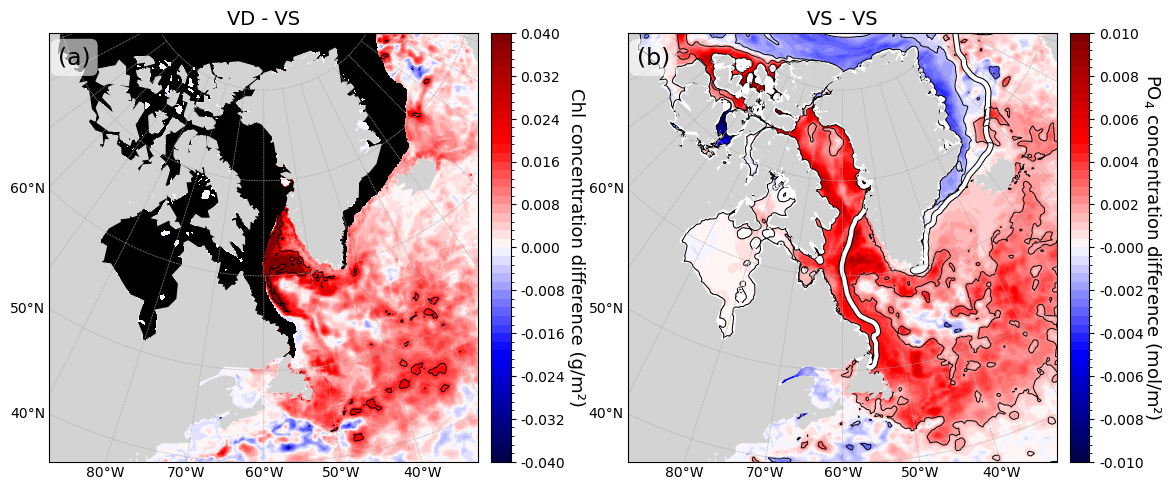

In [137]:
vmins = [-0.040000, -0.01]
vmaxs = [0.040000, 0.01]
levels = 50
lv = (vmaxs[1] - vmins[1]) / levels
levels_cr = list(np.arange(vmins[1], vmaxs[1] + lv, lv))

n_levels = 50
levels_oc = np.linspace(vmins[0], vmaxs[0], n_levels + 1)

levels = [levels_oc, levels_cr]
pvals = [p_val_chl, p_val_po4]

cmap = plt.get_cmap('seismic')

fig, axes = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={'wspace': 0.35})

datasets = [dif_chl/1e6, dif_po4]
titles = ['VD - VS', 'VS - VS']
cb_labels = ['Chl concentration difference (g/m\u00B2)', 'PO$_4$ concentration difference (mol/m\u00B2)']

for i, (ax, data, title, cb_label, vmin, vmax, level, pval) in enumerate(zip(axes, datasets, titles, cb_labels, vmins, 
                                                                             vmaxs, levels, pvals)):
    m = Basemap(projection='aea', resolution='c',
                width=5E6, height=5E6, lat_0=63, lon_0=-60, ax=ax)
    
    cs = m.contourf(lon, lat, np.clip(data, vmin, vmax),
                    latlon=True, levels=level, cmap=cmap, vmin=vmin, vmax=vmax)
    
    x, y = m(lon, lat)
    m.contour(x, y, pval, levels=[0.01], colors='black', linewidths = 0.7)
    if i == 0:
        m.contourf(x, y, icemask_vd, colors='black')
    if i == 1:
        m.contour(x, y, avg_ice_cover, levels = [0.1], colors='black', linewidths = 4.5, zorder = 1)
        m.contour(x, y, avg_ice_cover, levels = [0.1], colors='white', linewidths = 3, zorder = 1)
        

    m.drawcoastlines(color='lightgray')
    m.fillcontinents(color='lightgray', lake_color='lightgray')
    m.drawmeridians(np.arange(0, 360, 10), labels=[0, 0, 0, 1], linewidth=0.6, color='darkgray', fontsize=10)
    m.drawparallels(np.arange(-90, 90, 10), labels=[1, 0, 0, 0], linewidth=0.6,  color='darkgray', fontsize=10)
    ax.set_title(title, fontsize=14)

    # Colorbar discreta com ticks bem distribuídos, incluindo min e max
    cax = fig.add_axes([ax.get_position().x1 + 0.01,
                        ax.get_position().y0,
                        0.015,
                        ax.get_position().height])
    norm = BoundaryNorm(level, ncolors=cmap.N, clip=True)
    
    n_ticks = 11
    ticks = np.linspace(level[0], level[-1], n_ticks)
    
    cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm,
                                  boundaries=level,
                                  ticks=ticks,
                                  spacing='proportional')
    cb.ax.tick_params(labelsize=10)
    if vmax > 20:
        cb.set_ticklabels([f"{t:.2f}" for t in ticks])
    else:
        cb.set_ticklabels([f"{t:.3f}" for t in ticks])
        
    cb.set_label(cb_label, rotation=270, labelpad=14, fontsize=13)

labels = ['a', 'b']

for i, ax in enumerate(axes):
    # Add corner label in the upper-left corner of each subplot
    ax.text(0.02, 0.97, f'({labels[i]})', transform=ax.transAxes,
            fontsize=17, va='top', ha='left',
           bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.6))
    
    
figure_title = 'Chl+Po4'
os.chdir('.../output_miscellaneous/po4')
#plt.savefig(figure_title + '.png', dpi=300, bbox_inches='tight')
plt.show()

In [78]:
os.chdir('.../output_miscellaneous')

v_vs = np.load('ANHA4-EJM010_DS_vomecrty_2004_2016.npz')
v_vs = v_vs['vomecrty']

v_vd = np.load('ANHA4-EJM012_DS_vomecrty_2004_2016.npz')
v_vd = v_vd['vomecrty']

po4_vs = np.load('ANHA4-EJM010_DS_po4_2004_2016.npz')
po4_vs = po4_vs['po4']

po4_vd = np.load('ANHA4-EJM012_DS_po4_2004_2016.npz')
po4_vd = po4_vd['po4']

In [93]:
lat_ds = 440
lon_ds = np.arange(168, 218)

last_level = 32 #southward transport os phosphate until 500m

slice_e1v = e1v[0, lat_ds, lon_ds]

slice_e1v = last_level*[slice_e1v]

e3t_v = e3t[0:last_level]
e3t_v = 50*[e3t_v]
e3t_v = np.transpose(e3t_v)

v_vs = v_vs[:, 0:last_level, :]
v_vd = v_vd[:, 0:last_level, :]

po4_vs = po4_vs[:, 0:last_level, :]
po4_vd = po4_vd[:, 0:last_level, :]

v_vs[v_vs > 0] = np.nan
v_vd[v_vd > 0] = np.nan

vt_po4_vs = []
vt_po4_vd = []

for day in range(len(v_vs)):
    mult1 = np.multiply(po4_vs[day], v_vs[day])
    mult2 = np.multiply(mult1, slice_e1v)
    mult3 = np.multiply(mult2, e3t_v)
    vt_po4_sum = np.nansum(mult3)
    vt_po4_vs.append(vt_po4_sum)
    
for day in range(len(v_vs)):
    mult1 = np.multiply(po4_vd[day], v_vd[day])
    mult2 = np.multiply(mult1, slice_e1v)
    mult3 = np.multiply(mult2, e3t_v)
    vt_po4_sum = np.nansum(mult3)
    vt_po4_vd.append(vt_po4_sum)

vt_po4_vs = np.array(vt_po4_vs)
vt_po4_vd = np.array(vt_po4_vd)

dif_ds = vt_po4_vd - vt_po4_vs

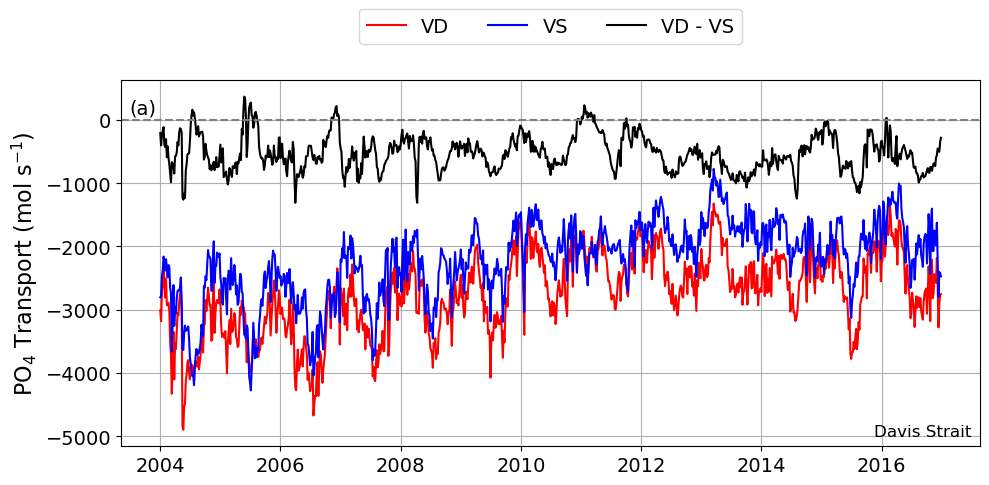

In [109]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=True)

ax.plot(vt_po4_vd, color='red')
ax.plot(vt_po4_vs, color='blue')
ax.plot(dif_ds, color='black')
ax.axhline(y=0, color='grey', linestyle='--')
ax.grid(True)

ax.tick_params(axis='y', labelsize=14)
ax.set_ylabel('PO$_4$ Transport (mol s$^{-1}$)', fontsize = 16)

ax.legend(['VD', 'VS', 'VD - VS'], fontsize=14, loc='upper center', bbox_to_anchor=(0.5, 1.22), ncol=3)

ax.text(0.01, 0.95, '(a)', fontsize=14, transform=ax.transAxes, va='top')

ax.text(0.99, 0.02, 'Davis Strait', transform=ax.transAxes, ha='right', va='bottom', fontsize=12)

year_ticks = np.arange(0, 1022, 73 * 2)
year_labels = np.arange(2004, 2017, 2)

ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, fontsize = 14)

plt.tight_layout()

outdir = '.../Figure8_JLS_NS_VolumeTransport'

plt.savefig(os.path.join(outdir, 'po4_Transport_DS.png'), dpi=300, bbox_inches='tight')

plt.show()

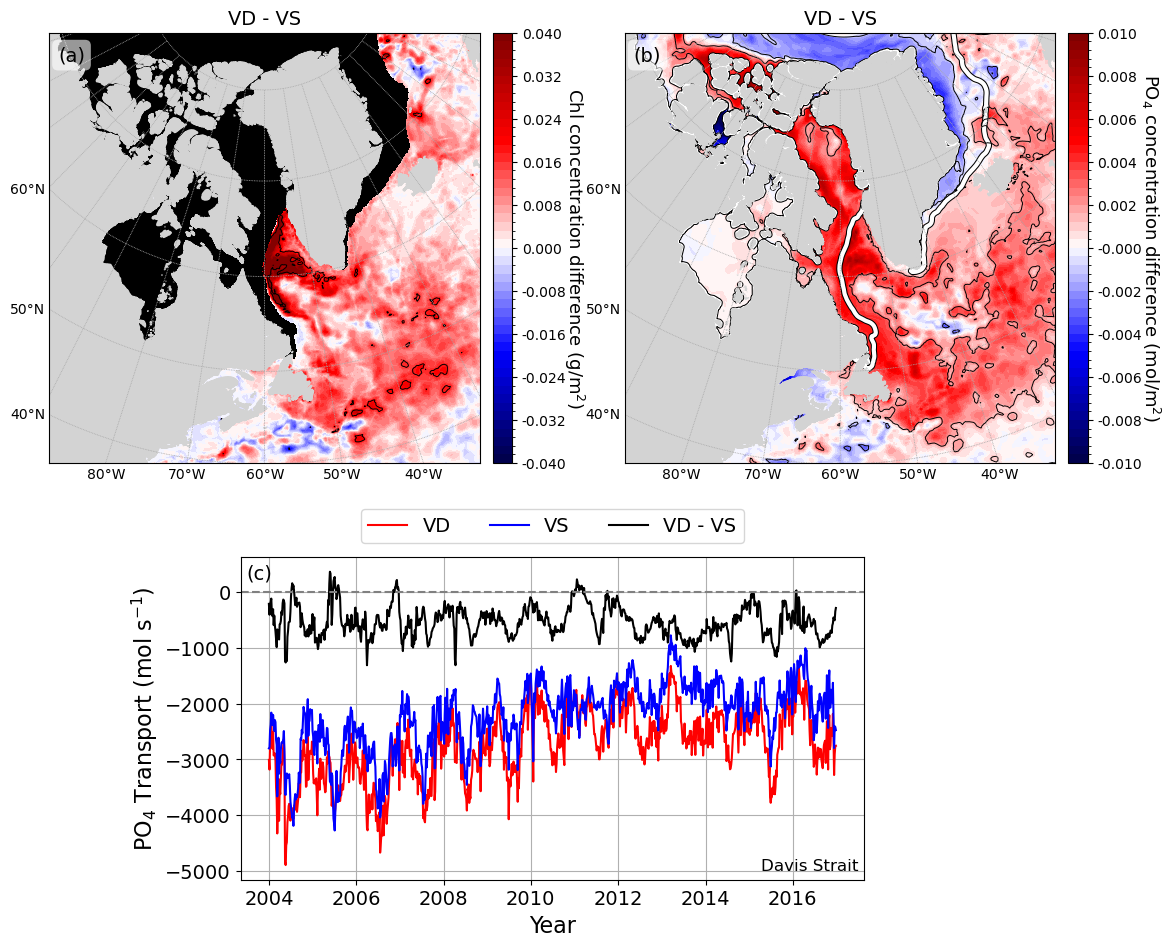

In [138]:
vmins = [-0.040000, -0.01]
vmaxs = [0.040000, 0.01]
levels = 50
lv = (vmaxs[1] - vmins[1]) / levels
levels_cr = list(np.arange(vmins[1], vmaxs[1] + lv, lv))

n_levels = 50
levels_oc = np.linspace(vmins[0], vmaxs[0], n_levels + 1)
levels = [levels_oc, levels_cr]
pvals = [p_val_chl, p_val_po4]

cmap = plt.get_cmap('seismic')

fig = plt.figure(figsize=(13, 11))
gs = fig.add_gridspec(nrows=2, ncols=6, height_ratios=[1, 0.75], hspace=0.25, wspace=3)

axes_maps = [fig.add_subplot(gs[0, 0:3]),fig.add_subplot(gs[0, 3:6])]

ax = fig.add_subplot(gs[1, 1:5])

datasets = [dif_chl / 1e6, dif_po4]
titles = ['VD - VS', 'VD - VS']
cb_labels = ['Chl concentration difference (g/m$^2$)', 'PO$_4$ concentration difference (mol/m$^2$)']
labels = ['a', 'b']

for i, (ax_map, data, title, cb_label, vmin, vmax, level, pval) in enumerate(zip(axes_maps, datasets, titles, cb_labels, vmins, vmaxs, levels, pvals)):
    m = Basemap(projection='aea', resolution='f', width=5E6, height=5E6, lat_0=63, lon_0=-60, ax=ax_map)
    cs = m.contourf(lon, lat, np.clip(data, vmin, vmax), latlon=True, levels=level, cmap=cmap, vmin=vmin, vmax=vmax)
    x, y = m(lon, lat)
    m.contour(x, y, pval, levels=[0.01], colors='black', linewidths=0.7)

    if i == 0:
        m.contourf(x, y, icemask_vd, colors='black')

    if i == 1:
        m.contour(x, y, avg_ice_cover, levels=[0.1], colors='black', linewidths=4.5, zorder=1)
        m.contour(x, y, avg_ice_cover, levels=[0.1], colors='white', linewidths=3, zorder=1)

    m.drawcoastlines(color='lightgray')
    m.fillcontinents(color='lightgray', lake_color='lightgray')
    m.drawmeridians(np.arange(0, 360, 10), labels=[0, 0, 0, 1], linewidth=0.6, color='darkgray', fontsize=10)
    m.drawparallels(np.arange(-90, 90, 10), labels=[1, 0, 0, 0], linewidth=0.6, color='darkgray', fontsize=10)
    ax_map.set_title(title, fontsize=14)

    ax_map.text(0.02, 0.97, f'({labels[i]})', transform=ax_map.transAxes, fontsize=14, 
                va='top', ha='left', bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.6))

    cax = fig.add_axes([ax_map.get_position().x1 + 0.01, ax_map.get_position().y0, 0.015, ax_map.get_position().height])
    norm = BoundaryNorm(level, ncolors=cmap.N, clip=True)
    ticks = np.linspace(level[0], level[-1], 11)

    cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, boundaries=level, ticks=ticks, spacing='proportional')
    cb.ax.tick_params(labelsize=10)

    if vmax > 20:
        cb.set_ticklabels([f"{t:.2f}" for t in ticks])
    else:
        cb.set_ticklabels([f"{t:.3f}" for t in ticks])

    cb.set_label(cb_label, rotation=270, labelpad=14, fontsize=13)

ax.plot(vt_po4_vd, color='red')
ax.plot(vt_po4_vs, color='blue')
ax.plot(dif_ds, color='black')
ax.axhline(y=0, color='grey', linestyle='--')
ax.grid(True)

ax.tick_params(axis='both', labelsize=14)
ax.set_ylabel('PO$_4$ Transport (mol s$^{-1}$)', fontsize=16)
ax.set_xlabel('Year', fontsize=16)

ax.legend(['VD', 'VS', 'VD - VS'], fontsize=14, loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=3)

ax.text(0.01, 0.98, '(c)', fontsize=14, transform=ax.transAxes, va='top')
ax.text(0.99, 0.02, 'Davis Strait', transform=ax.transAxes, ha='right', va='bottom', fontsize=12)

year_ticks = np.arange(0, 949, 73 * 2)
year_labels = np.arange(2004, 2018, 2)

ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, fontsize=14)

outdir = '.../Figure14_Chl_PO4_PO4transport'
os.makedirs(outdir, exist_ok=True)

plt.savefig(os.path.join(outdir, 'Chl_PO4_PO4transport_DS.png'), dpi=300, bbox_inches='tight')
plt.show()